PASS@1 EVALUATION - PHASE 2

[1/5] Loading Phase 2 results...
✓ Loaded 50,000 cases

Columns available: ['case', 'num_options', 'random_chance', 'true_diagnosis', 'predicted', 'raw_response', 'confidence', 'high_confidence', 'is_severe', 'action', 'refer_reason', 'correct']
✓ Converted column types
✓ Severe diseases defined: 21
  Cases with severe true diagnosis: 18,658

[2/5] Calculating Pass@1 metrics (strict criteria)...

📈 Pass@1 Results (Strict Criteria):
   Total cases: 50,000
   ✅ Correct (top-1, eligible): 26,707
   ❌ Wrong (eligible but incorrect): 21,618
   ❌ Excluded — low confidence (≤ 50%): 1,675
   ❌ Excluded — severe not referred: 0
   ⭐ Pass@1 Accuracy: 26,707/50,000 = 53.41%

[3/5] Analyzing by referral decision...

✅ DIAGNOSED CASES:
   Count: 17,061 (34.1% coverage)
   Correct: 17061/17061
   Accuracy: 100.00%

⚠️  REFERRED CASES:
   Count: 32,939 (65.9%)
   Accuracy (if diagnosed): 29.75%

   Referral breakdown:
     → severe_disease: 20,195
     → incorrect_predict

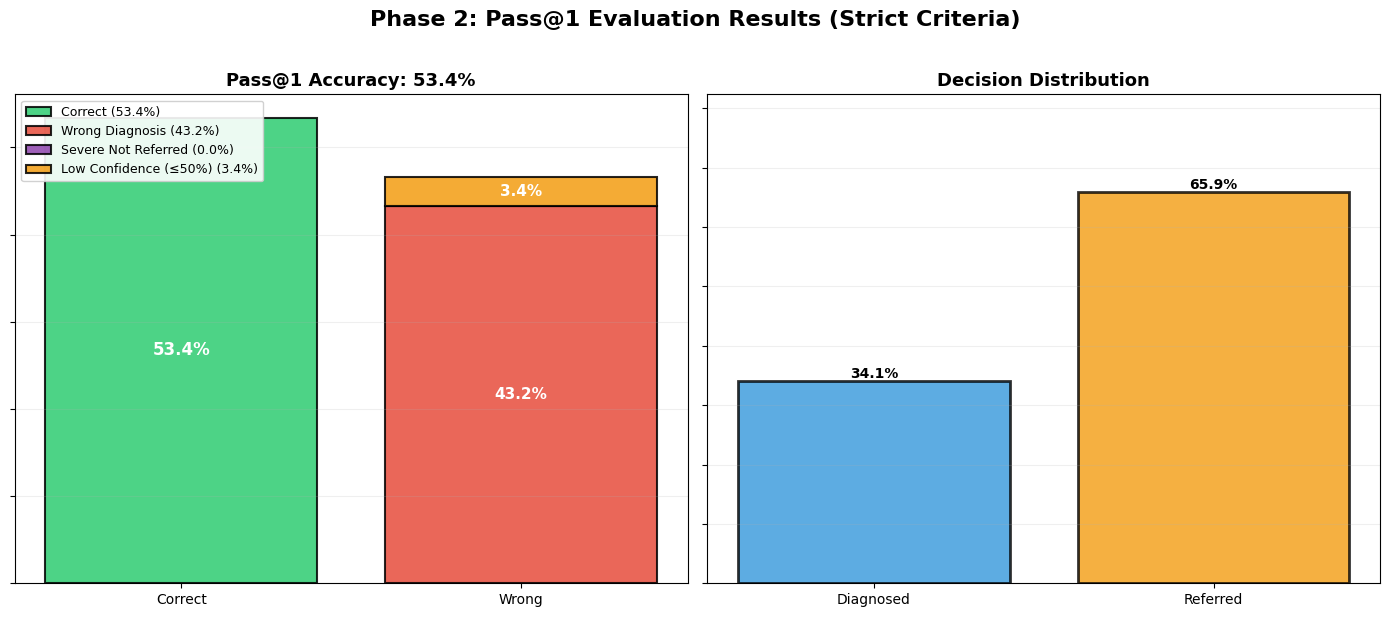

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("PASS@1 EVALUATION - PHASE 2")
print("="*70)

# ============================================
# 1. Load Results
# ============================================

print("\n[1/5] Loading Phase 2 results...")

df = pd.read_csv('phase2_results_50k.csv')

print(f"✓ Loaded {len(df):,} cases")
print(f"\nColumns available: {list(df.columns)}")

# ============================================
# 1b. Fix column types
# ============================================

TRUTHY = {'✓', '✔', '☑', 'true', 'True', '1', 'yes', 'Yes'}
df['diagnostic_correct'] = df['correct'].astype(str).str.strip().isin(TRUTHY)
df['final_is_referral']  = df['action'].astype(str).str.strip().eq('REFER')
df['rank1_confidence']   = pd.to_numeric(df['confidence'], errors='coerce')
df['rank1_disease']      = df['predicted'].astype(str).str.strip()

print("✓ Converted column types")

# ============================================
# 1c. Define severe diseases
# ============================================

SEVERE_DISEASES = {
    "Possible NSTEMI / STEMI",
    "Unstable angina",
    "Anaphylaxis",
    "Pulmonary embolism",
    "Spontaneous pneumothorax",
    "Acute pulmonary edema",
    "Epiglottitis",
    "Boerhaave",
    "Ebola",
    "HIV (initial infection)",
    "Tuberculosis",
    "Pancreatic neoplasm",
    "Pulmonary neoplasm",
    "Guillain-Barré syndrome",
    "Myasthenia gravis",
    "SLE",
    "Chagas",
    "Myocarditis",
    "Pericarditis",
    "Atrial fibrillation",
    "Sarcoidosis",
}

df['true_is_severe']   = df['true_diagnosis'].astype(str).str.strip().isin(SEVERE_DISEASES)
df['rank1_is_severe']  = df['rank1_disease'].isin(SEVERE_DISEASES)

print(f"✓ Severe diseases defined: {len(SEVERE_DISEASES)}")
print(f"  Cases with severe true diagnosis: {df['true_is_severe'].sum():,}")

# ============================================
# 2. Calculate Pass@1 (strict criteria)
# ============================================

print("\n[2/5] Calculating Pass@1 metrics (strict criteria)...")

total_cases = len(df)

# Severe disease diagnosed without referring = failure
df['severe_not_referred'] = (df['rank1_is_severe']) & (~df['final_is_referral'])

# High confidence cases
df['high_confidence'] = df['rank1_confidence'] > 0.5

# Eligible: high confidence AND not (severe + not referred)
eligible = df[(df['high_confidence']) & (~df['severe_not_referred'])]

eligible_correct = eligible['diagnostic_correct'].sum()
eligible_total   = len(eligible)
pass_at_1_accuracy = (eligible_correct / total_cases) * 100 if total_cases > 0 else 0.0

low_conf_cases   = df[~df['high_confidence']]
severe_unreferred = df[df['severe_not_referred']]

print(f"\n📈 Pass@1 Results (Strict Criteria):")
print(f"   Total cases: {total_cases:,}")
print(f"   ✅ Correct (top-1, eligible): {eligible_correct:,}")
print(f"   ❌ Wrong (eligible but incorrect): {eligible_total - eligible_correct:,}")
print(f"   ❌ Excluded — low confidence (≤ 50%): {len(low_conf_cases):,}")
print(f"   ❌ Excluded — severe not referred: {len(severe_unreferred):,}")
print(f"   ⭐ Pass@1 Accuracy: {eligible_correct:,}/{total_cases:,} = {pass_at_1_accuracy:.2f}%")

# ============================================
# 3. Breakdown by Referral Decision
# ============================================

print("\n[3/5] Analyzing by referral decision...")

diagnosed = df[df['final_is_referral'] == False]
referred  = df[df['final_is_referral'] == True]

diag_acc = 0.0
ref_acc  = 0.0

print(f"\n✅ DIAGNOSED CASES:")
print(f"   Count: {len(diagnosed):,} ({len(diagnosed)/total_cases*100:.1f}% coverage)")
if len(diagnosed) > 0:
    diag_correct = diagnosed['diagnostic_correct'].sum()
    diag_acc = (diag_correct / len(diagnosed)) * 100
    print(f"   Correct: {diag_correct}/{len(diagnosed)}")
    print(f"   Accuracy: {diag_acc:.2f}%")

print(f"\n⚠️  REFERRED CASES:")
print(f"   Count: {len(referred):,} ({len(referred)/total_cases*100:.1f}%)")
if len(referred) > 0:
    ref_correct = referred['diagnostic_correct'].sum()
    ref_acc = (ref_correct / len(referred)) * 100
    print(f"   Accuracy (if diagnosed): {ref_acc:.2f}%")

    # Breakdown by refer reason
    print(f"\n   Referral breakdown:")
    for reason, count in df['refer_reason'].value_counts(dropna=True).items():
        print(f"     → {reason}: {count:,}")

if len(diagnosed) > 0 and len(referred) > 0:
    if diag_acc > ref_acc:
        print(f"\n⛑ SAFETY CHECK: ✅ PASSED")
        print(f"   Diagnosed accuracy ({diag_acc:.1f}%) > Referred ({ref_acc:.1f}%)")
    else:
        print(f"\n⛑ SAFETY CHECK: ⚠️ NEEDS IMPROVEMENT")

# ============================================
# 4. Confidence Analysis
# ============================================

print("\n[4/5] Confidence analysis...")

avg_conf_all     = df['rank1_confidence'].mean()
avg_conf_correct = df[df['diagnostic_correct'] == True]['rank1_confidence'].mean()
avg_conf_wrong   = df[df['diagnostic_correct'] == False]['rank1_confidence'].mean()

print(f"\n📊 Confidence Statistics:")
print(f"   Average (all cases): {avg_conf_all:.1%}")
print(f"   Average (correct): {avg_conf_correct:.1%}")
print(f"   Average (wrong): {avg_conf_wrong:.1%}")

if avg_conf_correct > avg_conf_wrong:
    print(f"\n✅ Good calibration: Model more confident when correct")
else:
    print(f"\n⚠️  Poor calibration: Model not more confident when correct")

# ============================================
# 5. Visualizations
# ============================================

print("\n[5/5] Creating visualizations...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phase 2: Pass@1 Evaluation Results (Strict Criteria)', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Pass@1 Accuracy — Correct vs failure types
eligible_wrong  = eligible_total - eligible_correct
n_low_conf      = len(low_conf_cases)
n_severe_unref  = len(severe_unreferred)

correct_pct = eligible_correct / total_cases * 100
ax1.bar('Correct', eligible_correct, color='#2ecc71', alpha=0.85,
        edgecolor='black', linewidth=1.5, label=f'Correct ({correct_pct:.1f}%)')
ax1.text(0, eligible_correct / 2, f'{correct_pct:.1f}%',
         ha='center', va='center', fontweight='bold', fontsize=12, color='white')

wrong_segments = [eligible_wrong, n_severe_unref, n_low_conf]
wrong_labels   = ['Wrong Diagnosis', 'Severe Not Referred', 'Low Confidence (≤50%)']
wrong_colors   = ['#e74c3c', '#8e44ad', '#f39c12']

bottom = 0
for val, label, color in zip(wrong_segments, wrong_labels, wrong_colors):
    pct = val / total_cases * 100
    ax1.bar('Wrong', val, bottom=bottom, color=color, alpha=0.85,
            edgecolor='black', linewidth=1.5, label=f'{label} ({pct:.1f}%)')
    if pct >= 1:
        ax1.text(1, bottom + val / 2, f'{pct:.1f}%',
                 ha='center', va='center', fontweight='bold', fontsize=11, color='white')
    bottom += val

ax1.set_ylabel('')
ax1.set_title(f'Pass@1 Accuracy: {pass_at_1_accuracy:.1f}%', fontweight='bold', fontsize=13)
ax1.set_yticklabels([])
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.2, axis='y')

# Plot 2: Decision Distribution
categories = ['Diagnosed', 'Referred']
counts = [len(diagnosed), len(referred)]
colors = ['#3498db', '#f39c12']
bars = ax2.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('')
ax2.set_title('Decision Distribution', fontweight='bold', fontsize=13)
ax2.set_ylim(0, max(counts) * 1.25 if max(counts) > 0 else 10)
ax2.set_yticklabels([])

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count/total_cases*100:.1f}%',
             ha='center', va='bottom', fontweight='bold')
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('phase2_pass_at_1_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: phase2_pass_at_1_analysis.png")

# ============================================
# 6. Summary Report
# ============================================

print("\n" + "="*70)
print("PASS@1 EVALUATION SUMMARY")
print("="*70)

diag_acc_str     = f"{diag_acc:.2f}%" if len(diagnosed) > 0 else "N/A"
calibration_str  = "✅ Good" if avg_conf_correct > avg_conf_wrong else "⚠️ Poor"
safety_str       = "✅ Passed" if (len(diagnosed) > 0 and len(referred) > 0 and diag_acc > ref_acc) else "⚠️ Check"

print(f"""
📊 PHASE 2 RESULTS (STRICT PASS@1 CRITERIA):

Pass@1 Criteria:
  • Only cases with confidence > 50%
  • Severe diseases diagnosed without referral count as FAILURES
  • Denominator = ALL cases (excluded cases are failures, not removals)

Pass@1 Accuracy: {pass_at_1_accuracy:.2f}%
  • Correct: {eligible_correct:,}/{total_cases:,} total cases

Breakdown of all {total_cases:,} cases:
  • ✅ Correct (eligible, right diagnosis): {eligible_correct:,}
  • ❌ Wrong (eligible, wrong diagnosis): {eligible_total - eligible_correct:,}
  • ❌ Failed — low confidence (≤ 50%): {len(low_conf_cases):,}
  • ❌ Failed — severe not referred: {len(severe_unreferred):,}

Decision Breakdown:
  • Diagnosed: {len(diagnosed):,} ({len(diagnosed)/total_cases*100:.1f}%)
  • Referred: {len(referred):,} ({len(referred)/total_cases*100:.1f}%)

Diagnosed Cases Accuracy: {diag_acc_str}

Confidence Calibration:
  • Avg confidence (correct): {avg_conf_correct:.1%}
  • Avg confidence (wrong): {avg_conf_wrong:.1%}
  • Calibration: {calibration_str}

Key Metrics:
  • Pass@1: {pass_at_1_accuracy:.2f}%
  • Safety: {safety_str}

Files Generated:
  ✓ phase2_pass_at_1_analysis.png (visualization)

Ready to compare with Phase 1 results!
""")

print("="*70)
print("✅ PASS@1 EVALUATION COMPLETE")
print("="*70)

CONFIDENCE TREND VISUALIZATION - PHASE 2

[1/3] Loading data...
✓ Loaded 50,000 cases
  Correct: 26,859 | Wrong: 23,141
  Overall accuracy: 53.72%

[2/3] Generating plot...
✓ Saved: phase2_confidence_trends.png

CONFIDENCE TREND SUMMARY

  Correct diagnoses:
    mean: 0.7705    median: 0.7818    std: 0.1023

  Wrong diagnoses:
    mean: 0.6731    median: 0.6730    std: 0.1145

  Confidence gap (correct - wrong): +0.0974

  ✅ Model is noticeably more confident when correct — good calibration signal

✅ CONFIDENCE TREND VISUALIZATION COMPLETE


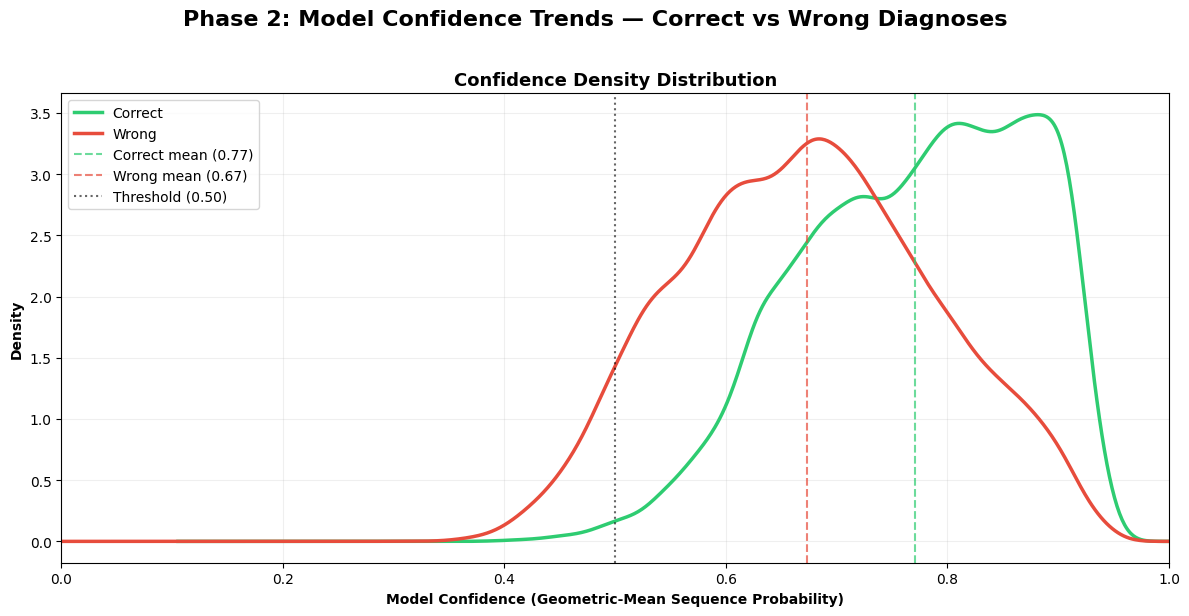

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("CONFIDENCE TREND VISUALIZATION - PHASE 2")
print("="*70)

# ============================================
# 1. Load and prepare data
# ============================================

print("\n[1/3] Loading data...")

df = pd.read_csv('phase2_results_50k.csv')

TRUTHY = {'✓', '✔', '☑', 'true', 'True', '1', 'yes', 'Yes'}
df['diagnostic_correct'] = df['correct'].astype(str).str.strip().isin(TRUTHY)
df['rank1_confidence']   = pd.to_numeric(df['confidence'], errors='coerce')

correct_conf = df[df['diagnostic_correct'] == True]['rank1_confidence'].dropna()
wrong_conf   = df[df['diagnostic_correct'] == False]['rank1_confidence'].dropna()

total    = len(df)
n_correct = df['diagnostic_correct'].sum()
overall_acc = (n_correct / total) * 100

print(f"✓ Loaded {total:,} cases")
print(f"  Correct: {n_correct:,} | Wrong: {total - n_correct:,}")
print(f"  Overall accuracy: {overall_acc:.2f}%")

# ============================================
# 2. Create visualization
# ============================================

print("\n[2/3] Generating plot...")

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Phase 2: Model Confidence Trends — Correct vs Wrong Diagnoses',
             fontsize=16, fontweight='bold', y=1.02)

if len(correct_conf) > 1:
    correct_conf.plot.kde(ax=ax, color='#2ecc71', linewidth=2.5, label='Correct')
if len(wrong_conf) > 1:
    wrong_conf.plot.kde(ax=ax, color='#e74c3c', linewidth=2.5, label='Wrong')

ax.axvline(correct_conf.mean(), color='#2ecc71', linestyle='--', alpha=0.7, linewidth=1.5,
           label=f'Correct mean ({correct_conf.mean():.2f})')
ax.axvline(wrong_conf.mean(), color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5,
           label=f'Wrong mean ({wrong_conf.mean():.2f})')
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6, label='Threshold (0.50)')

ax.set_xlabel('Model Confidence (Geometric-Mean Sequence Probability)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Confidence Density Distribution', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('phase2_confidence_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: phase2_confidence_trends.png")

# ============================================
# 3. Summary statistics
# ============================================

print(f"\n{'='*70}")
print(f"CONFIDENCE TREND SUMMARY")
print(f"{'='*70}")

print(f"""
  Correct diagnoses:
    mean: {correct_conf.mean():.4f}    median: {correct_conf.median():.4f}    std: {correct_conf.std():.4f}

  Wrong diagnoses:
    mean: {wrong_conf.mean():.4f}    median: {wrong_conf.median():.4f}    std: {wrong_conf.std():.4f}

  Confidence gap (correct - wrong): {correct_conf.mean() - wrong_conf.mean():+.4f}
""")

conf_gap = correct_conf.mean() - wrong_conf.mean()
if conf_gap > 0.05:
    print("  ✅ Model is noticeably more confident when correct — good calibration signal")
elif conf_gap > 0:
    print("  ⚠️  Model is slightly more confident when correct — weak signal")
else:
    print("  ❌ Model is NOT more confident when correct — poor calibration")

print(f"\n{'='*70}")
print("✅ CONFIDENCE TREND VISUALIZATION COMPLETE")
print(f"{'='*70}")

MISSED REFERRAL ANALYSIS - PHASE 2

[1/3] Loading data...
✓ Loaded 50,000 cases
  Severe disease cases: 18,658 (37.3%)
  Correctly referred: 18,516 (99.2%)
  ❌ Missed referrals: 142 (0.8%)

[2/3] Generating plots...
✓ Saved: phase2_missed_referrals.png

MISSED REFERRAL SUMMARY

  Total cases: 50,000
  Severe disease cases: 18,658 (37.3% of all cases)

  Correctly referred: 18,516 (99.2% of severe)
  ❌ Missed referrals: 142 (0.8% of severe)

  Among missed referrals:
    Diagnosed correctly (but should have referred): 142
    Diagnosed incorrectly: 0
    Average confidence: 0.663

  Top missed diseases:
    Unstable angina: 142 missed

  ✅ Referral rate is strong at 99.2%

✅ MISSED REFERRAL ANALYSIS COMPLETE


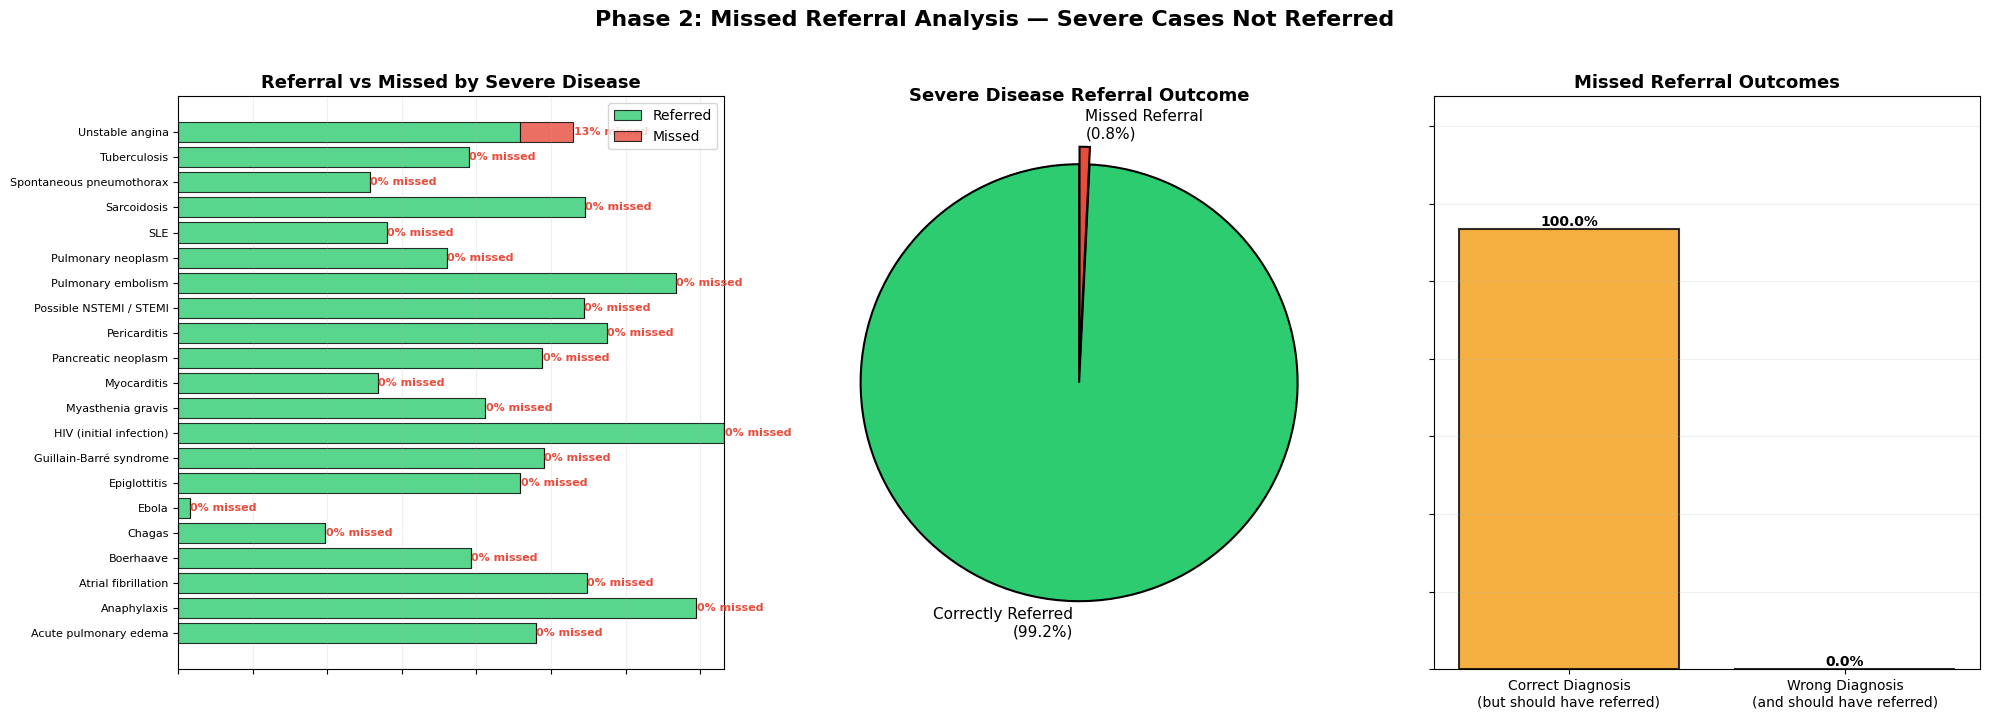

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("MISSED REFERRAL ANALYSIS - PHASE 2")
print("="*70)

# ============================================
# 1. Load and prepare data
# ============================================

print("\n[1/3] Loading data...")

df = pd.read_csv('phase2_results_50k.csv')

TRUTHY = {'✓', '✔', '☑', 'true', 'True', '1', 'yes', 'Yes'}
df['diagnostic_correct'] = df['correct'].astype(str).str.strip().isin(TRUTHY)
df['final_is_referral']  = df['action'].astype(str).str.strip().eq('REFER')
df['rank1_confidence']   = pd.to_numeric(df['confidence'], errors='coerce')
df['rank1_disease']      = df['predicted'].astype(str).str.strip()

SEVERE_DISEASES = {
    "Possible NSTEMI / STEMI", "Unstable angina", "Anaphylaxis", "Pulmonary embolism",
    "Spontaneous pneumothorax", "Acute pulmonary edema", "Epiglottitis", "Boerhaave",
    "Ebola", "HIV (initial infection)", "Tuberculosis", "Pancreatic neoplasm",
    "Pulmonary neoplasm", "Guillain-Barré syndrome", "Myasthenia gravis", "SLE",
    "Chagas", "Myocarditis", "Pericarditis", "Atrial fibrillation", "Sarcoidosis",
}

df['true_is_severe']  = df['true_diagnosis'].astype(str).str.strip().isin(SEVERE_DISEASES)
df['rank1_is_severe'] = df['rank1_disease'].isin(SEVERE_DISEASES)

# Key groups
severe_cases    = df[df['true_is_severe']]
severe_referred = severe_cases[severe_cases['final_is_referral'] == True]
severe_missed   = severe_cases[severe_cases['final_is_referral'] == False]

total          = len(df)
n_severe       = len(severe_cases)
n_referred     = len(severe_referred)
n_missed       = len(severe_missed)
referral_rate  = (n_referred / n_severe * 100) if n_severe > 0 else 0.0
miss_rate      = (n_missed  / n_severe * 100) if n_severe > 0 else 0.0

print(f"✓ Loaded {total:,} cases")
print(f"  Severe disease cases: {n_severe:,} ({n_severe/total*100:.1f}%)")
print(f"  Correctly referred: {n_referred:,} ({referral_rate:.1f}%)")
print(f"  ❌ Missed referrals: {n_missed:,} ({miss_rate:.1f}%)")

# ============================================
# 2. Create visualizations
# ============================================

print("\n[2/3] Generating plots...")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Phase 2: Missed Referral Analysis — Severe Cases Not Referred',
             fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Referral rate per severe disease ──
ax = axes[0]
if n_severe > 0:
    disease_stats = severe_cases.groupby('true_diagnosis').agg(
        total=('final_is_referral', 'count'),
        referred=('final_is_referral', 'sum')
    ).reset_index()
    disease_stats['missed']    = disease_stats['total'] - disease_stats['referred']
    disease_stats['miss_rate'] = (disease_stats['missed'] / disease_stats['total']) * 100
    disease_stats = disease_stats.sort_values('miss_rate', ascending=True)

    y_pos = np.arange(len(disease_stats))
    ax.barh(y_pos, disease_stats['referred'], color='#2ecc71', alpha=0.8,
            edgecolor='black', linewidth=0.8, label='Referred')
    ax.barh(y_pos, disease_stats['missed'], left=disease_stats['referred'],
            color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.8, label='Missed')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(disease_stats['true_diagnosis'], fontsize=8)
    ax.set_title('Referral vs Missed by Severe Disease', fontweight='bold', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xticklabels([])

    for i, (_, row) in enumerate(disease_stats.iterrows()):
        miss_pct = row['miss_rate']
        ax.text(row['total'] + 0.3, i, f"{miss_pct:.0f}% missed",
                va='center', fontsize=8, color='#e74c3c', fontweight='bold')
ax.grid(True, alpha=0.2, axis='x')

# ── Plot 2: Overall referral outcome pie ──
ax = axes[1]
if n_severe > 0:
    sizes   = [n_referred, n_missed]
    labels  = [f'Correctly Referred\n({referral_rate:.1f}%)',
                f'Missed Referral\n({miss_rate:.1f}%)']
    colors  = ['#2ecc71', '#e74c3c']
    explode = (0, 0.08)
    ax.pie(sizes, labels=labels, colors=colors, explode=explode,
           autopct='', startangle=90, textprops={'fontsize': 11},
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
    ax.set_title('Severe Disease Referral Outcome', fontweight='bold', fontsize=13)
else:
    ax.text(0.5, 0.5, 'No severe cases found', ha='center', va='center', fontsize=14)
    ax.set_title('Severe Disease Referral Outcome', fontweight='bold', fontsize=13)

# ── Plot 3: Missed referrals — was the diagnosis at least correct? ──
ax = axes[2]
if n_missed > 0:
    missed_correct = severe_missed['diagnostic_correct'].sum()
    missed_wrong   = n_missed - missed_correct

    categories = ['Correct Diagnosis\n(but should have referred)',
                  'Wrong Diagnosis\n(and should have referred)']
    counts  = [missed_correct, missed_wrong]
    colors  = ['#f39c12', '#e74c3c']
    bars    = ax.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_title('Missed Referral Outcomes', fontweight='bold', fontsize=13)
    ax.set_ylim(0, max(counts) * 1.3 if max(counts) > 0 else 10)
    ax.set_yticklabels([])

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count/n_missed*100:.1f}%',
                ha='center', va='bottom', fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')
else:
    ax.text(0.5, 0.5, '✅ No missed referrals!', ha='center', va='center',
            fontsize=16, fontweight='bold', color='#2ecc71')
    ax.set_title('Missed Referral Outcomes', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('phase2_missed_referrals.png', dpi=300, bbox_inches='tight')
print("✓ Saved: phase2_missed_referrals.png")

# ============================================
# 3. Summary
# ============================================

print(f"\n{'='*70}")
print("MISSED REFERRAL SUMMARY")
print(f"{'='*70}")

print(f"""
  Total cases: {total:,}
  Severe disease cases: {n_severe:,} ({n_severe/total*100:.1f}% of all cases)

  Correctly referred: {n_referred:,} ({referral_rate:.1f}% of severe)
  ❌ Missed referrals: {n_missed:,} ({miss_rate:.1f}% of severe)
""")

if n_missed > 0:
    missed_correct   = severe_missed['diagnostic_correct'].sum()
    missed_wrong     = n_missed - missed_correct
    avg_missed_conf  = severe_missed['rank1_confidence'].mean()

    print(f"  Among missed referrals:")
    print(f"    Diagnosed correctly (but should have referred): {missed_correct:,}")
    print(f"    Diagnosed incorrectly: {missed_wrong:,}")
    print(f"    Average confidence: {avg_missed_conf:.3f}")

    print(f"\n  Top missed diseases:")
    missed_by_disease = severe_missed['true_diagnosis'].value_counts()
    for disease, count in missed_by_disease.items():
        print(f"    {disease}: {count:,} missed")

    if miss_rate > 20:
        print(f"\n  ❌ CRITICAL: {miss_rate:.1f}% of severe cases were not referred")
    elif miss_rate > 5:
        print(f"\n  ⚠️  WARNING: {miss_rate:.1f}% of severe cases were not referred")
    else:
        print(f"\n  ✅ Referral rate is strong at {referral_rate:.1f}%")
else:
    print("  ✅ All severe cases were correctly referred!")

print(f"\n{'='*70}")
print("✅ MISSED REFERRAL ANALYSIS COMPLETE")
print(f"{'='*70}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

print("="*70)
print("PASS@1 F1 SCORE CALCULATION - PHASE 2 (Strict Criteria)")
print("="*70)

# ============================================
# 1. Load and prepare data
# ============================================

print("\n[1/2] Loading and preparing data for F1 score calculation...")

df = pd.read_csv('phase2_results_50k.csv')

TRUTHY = {'✓', '✔', '☑', 'true', 'True', '1', 'yes', 'Yes'}
df['diagnostic_correct'] = df['correct'].astype(str).str.strip().isin(TRUTHY)
df['final_is_referral']  = df['action'].astype(str).str.strip().eq('REFER')
df['rank1_confidence']   = pd.to_numeric(df['confidence'], errors='coerce')
df['rank1_disease']      = df['predicted'].astype(str).str.strip()

SEVERE_DISEASES = {
    "Possible NSTEMI / STEMI", "Unstable angina", "Anaphylaxis", "Pulmonary embolism",
    "Spontaneous pneumothorax", "Acute pulmonary edema", "Epiglottitis", "Boerhaave",
    "Ebola", "HIV (initial infection)", "Tuberculosis", "Pancreatic neoplasm",
    "Pulmonary neoplasm", "Guillain-Barré syndrome", "Myasthenia gravis", "SLE",
    "Chagas", "Myocarditis", "Pericarditis", "Atrial fibrillation", "Sarcoidosis",
}
df['rank1_is_severe']     = df['rank1_disease'].isin(SEVERE_DISEASES)
df['severe_not_referred'] = (df['rank1_is_severe']) & (~df['final_is_referral'])
df['high_confidence']     = df['rank1_confidence'] > 0.5

print(f"✓ Loaded and prepared {len(df):,} cases")

# ============================================
# 2. Calculate Pass@1 Metrics
# ============================================

print("\n[2/2] Calculating binary Pass@1 metrics...")

is_pass_at_1_success = (
    df['diagnostic_correct'] &
    df['high_confidence'] &
    ~df['severe_not_referred']
)

overall_pass_at_1_accuracy = is_pass_at_1_success.sum() / len(df)
print(f"\nOverall Pass@1 Accuracy: {overall_pass_at_1_accuracy:.4f} ({overall_pass_at_1_accuracy*100:.2f}%)")

y_true_for_metrics = df['diagnostic_correct'].astype(int)
y_pred_for_metrics = (df['high_confidence'] & ~df['severe_not_referred']).astype(int)

binary_f1        = f1_score(y_true_for_metrics, y_pred_for_metrics, average='binary', pos_label=1, zero_division=0)
binary_precision = precision_score(y_true_for_metrics, y_pred_for_metrics, average='binary', pos_label=1, zero_division=0)
binary_recall    = recall_score(y_true_for_metrics, y_pred_for_metrics, average='binary', pos_label=1, zero_division=0)

print(f"\nPass@1 F1 Score        (Correct & Safe Diagnosis): {binary_f1:.4f}")
print(f"Pass@1 Precision       (Correct & Safe Diagnosis): {binary_precision:.4f}")
print(f"Pass@1 Recall          (Correct & Safe Diagnosis): {binary_recall:.4f}")

print("\n" + "="*70)
print("✅ PASS@1 F1 SCORE CALCULATION COMPLETE")
print("="*70)

PASS@1 F1 SCORE CALCULATION - PHASE 2 (Strict Criteria)

[1/2] Loading and preparing data for F1 score calculation...
✓ Loaded and prepared 50,000 cases

[2/2] Calculating binary Pass@1 metrics...

Overall Pass@1 Accuracy: 0.5341 (53.41%)

Pass@1 F1 Score        (Correct & Safe Diagnosis): 0.7104
Pass@1 Precision       (Correct & Safe Diagnosis): 0.5527
Pass@1 Recall          (Correct & Safe Diagnosis): 0.9943

✅ PASS@1 F1 SCORE CALCULATION COMPLETE
